In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Go to project root
os.chdir('C:/Users/HomePC/Documents/kifiya/news-sentiment-analysis')

plt.style.use('ggplot')
sns.set_palette('Set2')

print("✅ Libraries loaded")

✅ Libraries loaded


In [13]:
# Load news and stock data
news_df = pd.read_csv('data/raw/financial_news.csv', parse_dates=['date'])
stock_df = pd.read_csv('data/raw/stock_prices_clean.csv', parse_dates=['Date'])

print(f"News: {news_df.shape[0]} articles, {news_df['stock'].nunique()} stocks")
print(f"Stock: {stock_df.shape[0]} rows, {stock_df['Symbol'].nunique()} stocks")

News: 2000 articles, 10 stocks
Stock: 2510 rows, 10 stocks


In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Get sentiment score for each headline
news_df['sentiment'] = news_df['headline'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# Classify sentiment
news_df['sentiment_label'] = pd.cut(
    news_df['sentiment'], 
    bins=[-1, -0.05, 0.05, 1], 
    labels=['Negative', 'Neutral', 'Positive']
)

print("Sentiment distribution:")
print(news_df['sentiment_label'].value_counts())
print(f"\nSentiment range: {news_df['sentiment'].min():.3f} to {news_df['sentiment'].max():.3f}")
print(f"Mean sentiment: {news_df['sentiment'].mean():.3f}")

Sentiment distribution:
sentiment_label
Neutral     1195
Positive     412
Negative     393
Name: count, dtype: int64

Sentiment range: -0.440 to 0.511
Mean sentiment: -0.001


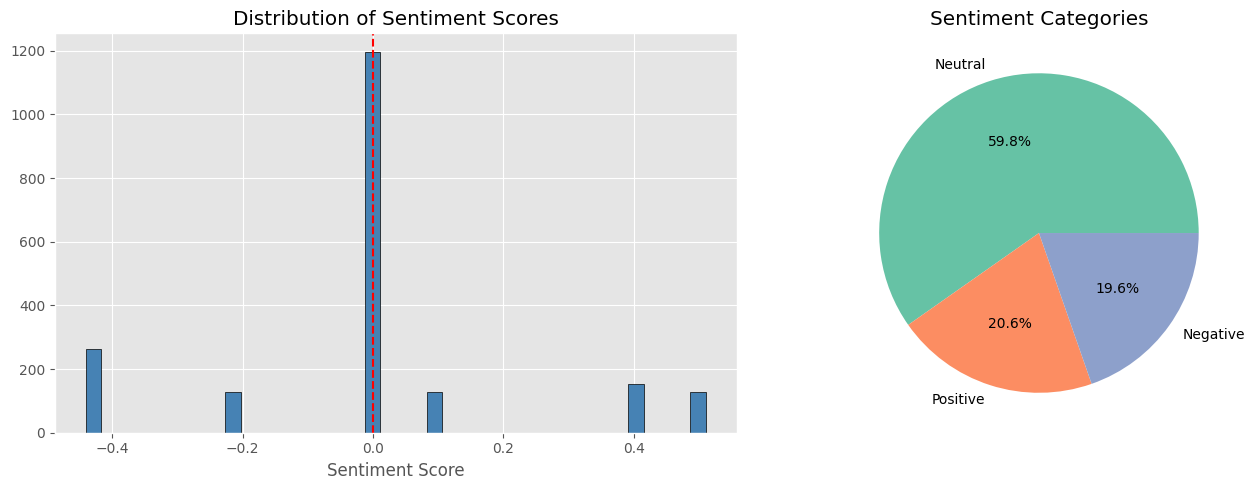

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(news_df['sentiment'], bins=40, edgecolor='black', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution of Sentiment Scores')
axes[0].set_xlabel('Sentiment Score')

# Pie chart
news_df['sentiment_label'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Sentiment Categories')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Calculate daily returns for each stock
stock_df = stock_df.sort_values(['Symbol', 'Date'])
stock_df['Daily_Return'] = stock_df.groupby('Symbol')['Close'].pct_change() * 100

# Drop NaN returns (first day of each stock)
stock_df = stock_df.dropna(subset=['Daily_Return'])

print("Daily return stats:")
print(stock_df['Daily_Return'].describe())

Daily return stats:
count    2500.000000
mean        0.113427
std         1.797122
min       -14.259894
25%        -0.786420
50%         0.105546
75%         1.005860
max        11.252713
Name: Daily_Return, dtype: float64


In [17]:
# News: extract just the date (no time)
news_df['date_only'] = news_df['date'].dt.date

# Average sentiment per stock per day
daily_sentiment = news_df.groupby(['date_only', 'stock'])['sentiment'].mean().reset_index()
daily_sentiment.columns = ['Date', 'Symbol', 'Avg_Sentiment']
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

# Also count articles per day
article_counts = news_df.groupby(['date_only', 'stock']).size().reset_index()
article_counts.columns = ['Date', 'Symbol', 'Article_Count']
article_counts['Date'] = pd.to_datetime(article_counts['Date'])

# Merge sentiment and counts
daily_sentiment = daily_sentiment.merge(article_counts, on=['Date', 'Symbol'])

print(f"Days with sentiment: {len(daily_sentiment)}")
print(daily_sentiment.head())

Days with sentiment: 1545
        Date Symbol  Avg_Sentiment  Article_Count
0 2025-01-01    JPM         0.0000              2
1 2025-01-01   META         0.5106              1
2 2025-01-01    PFE         0.0000              1
3 2025-01-02   AMZN         0.0000              1
4 2025-01-02    JPM         0.0000              1


In [18]:
# Merge on Date and Symbol
merged = stock_df.merge(daily_sentiment, on=['Date', 'Symbol'], how='inner')

# Also add sentiment category
merged['Sentiment_Cat'] = pd.cut(
    merged['Avg_Sentiment'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['Negative', 'Neutral', 'Positive']
)

print(f"Merged data: {len(merged)} rows")
print(f"Days with both news and returns: {len(merged)}")
print(merged[['Date', 'Symbol', 'Close', 'Daily_Return', 'Avg_Sentiment']].head())

Merged data: 709 rows
Days with both news and returns: 709
        Date Symbol       Close  Daily_Return  Avg_Sentiment
0 2025-05-16   AAPL  210.425201     -0.089851        0.10270
1 2025-05-21   AAPL  201.291428     -2.305911        0.40190
2 2025-05-22   AAPL  200.564316     -0.361223        0.05135
3 2025-05-29   AAPL  199.159882     -0.234514        0.00000
4 2025-05-30   AAPL  200.056335      0.450118        0.00000


In [19]:
# Pearson correlation
corr, p_value = stats.pearsonr(merged['Avg_Sentiment'], merged['Daily_Return'])

print("=" * 50)
print("CORRELATION RESULTS")
print("=" * 50)
print(f"Pearson Correlation: {corr:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")

# Per-stock correlation
print("\nPer-Stock Correlations:")
for symbol in merged['Symbol'].unique():
    sub = merged[merged['Symbol'] == symbol]
    if len(sub) > 10:
        c, p = stats.pearsonr(sub['Avg_Sentiment'], sub['Daily_Return'])
        print(f"  {symbol}: r={c:.3f}, p={p:.3f}")

CORRELATION RESULTS
Pearson Correlation: -0.0198
P-value: 0.598021
Statistically significant: No

Per-Stock Correlations:
  AAPL: r=-0.047, p=0.698
  AMZN: r=0.103, p=0.434
  BAC: r=-0.074, p=0.520
  GOOGL: r=-0.087, p=0.456
  JPM: r=0.071, p=0.550
  META: r=-0.201, p=0.083
  MSFT: r=-0.087, p=0.441
  PFE: r=-0.005, p=0.971
  TSLA: r=0.053, p=0.697
  WMT: r=0.121, p=0.308


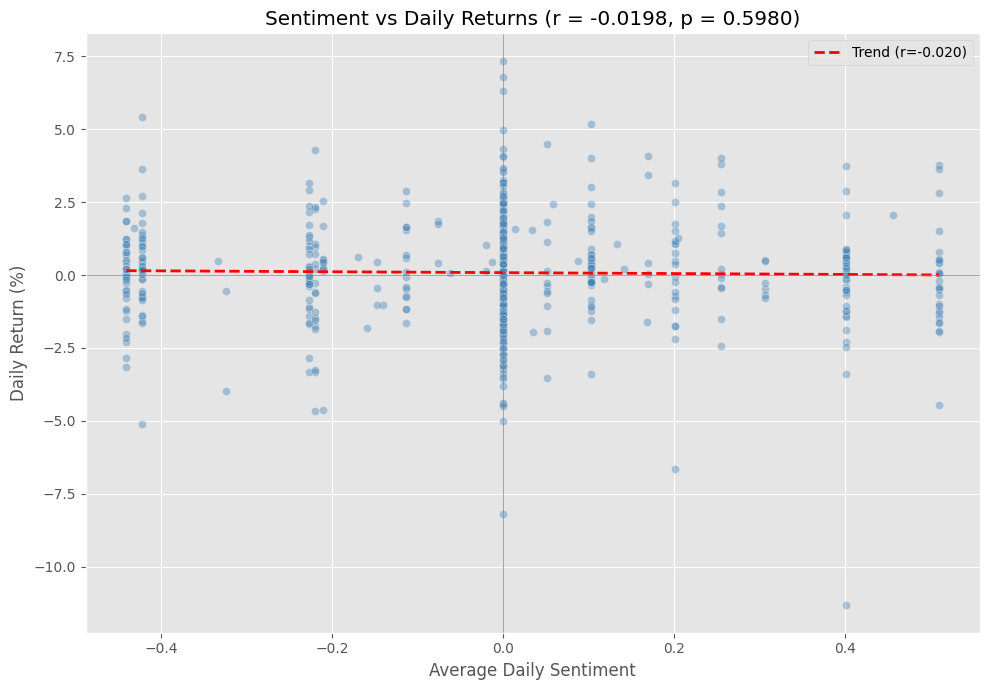

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(merged['Avg_Sentiment'], merged['Daily_Return'], 
           alpha=0.4, c='steelblue', edgecolors='white')

# Trend line
z = np.polyfit(merged['Avg_Sentiment'], merged['Daily_Return'], 1)
p = np.poly1d(z)
x_range = np.linspace(merged['Avg_Sentiment'].min(), merged['Avg_Sentiment'].max(), 100)
ax.plot(x_range, p(x_range), 'r--', linewidth=2, label=f'Trend (r={corr:.3f})')

ax.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)

ax.set_xlabel('Average Daily Sentiment')
ax.set_ylabel('Daily Return (%)')
ax.set_title(f'Sentiment vs Daily Returns (r = {corr:.4f}, p = {p_value:.4f})')
ax.legend()

plt.tight_layout()
plt.savefig('sentiment_vs_returns.png', dpi=150, bbox_inches='tight')
plt.show()

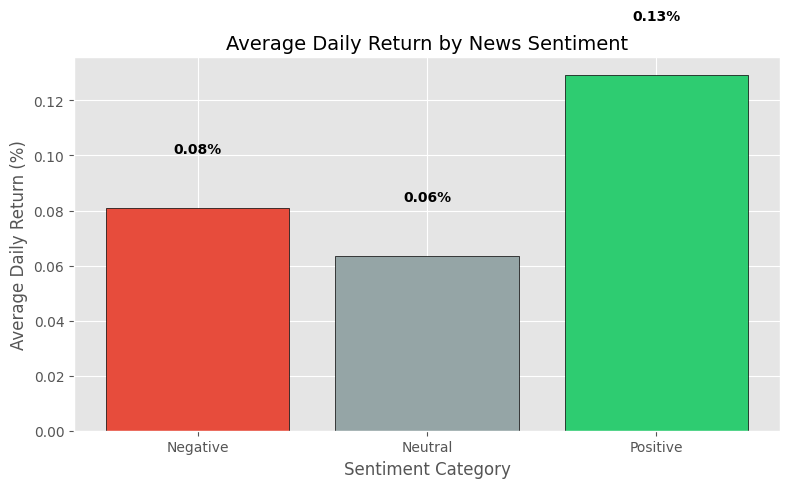

                   mean       std  count
Sentiment_Cat                           
Negative       0.080737  1.606995    166
Neutral        0.063478  1.648926    377
Positive       0.129153  1.909422    166


In [21]:
cat_stats = merged.groupby('Sentiment_Cat')['Daily_Return'].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
bars = ax.bar(cat_stats.index, cat_stats['mean'], color=colors, edgecolor='black')

# Add value labels
for bar, val in zip(bars, cat_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.15,
            f'{val:.2f}%', ha='center', fontweight='bold')

ax.set_title('Average Daily Return by News Sentiment', fontsize=14)
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Average Daily Return (%)')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('returns_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat_stats)

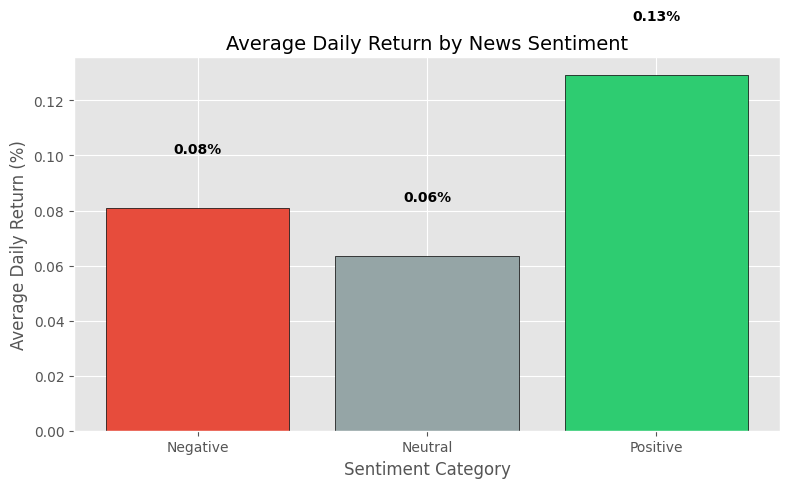

                   mean       std  count
Sentiment_Cat                           
Negative       0.080737  1.606995    166
Neutral        0.063478  1.648926    377
Positive       0.129153  1.909422    166


In [22]:
cat_stats = merged.groupby('Sentiment_Cat')['Daily_Return'].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
bars = ax.bar(cat_stats.index, cat_stats['mean'], color=colors, edgecolor='black')

# Add value labels
for bar, val in zip(bars, cat_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.15,
            f'{val:.2f}%', ha='center', fontweight='bold')

ax.set_title('Average Daily Return by News Sentiment', fontsize=14)
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Average Daily Return (%)')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('returns_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat_stats)